In [1]:
!pip install mlflow
!pip install python-dotenv
!pip install seaborn
!pip install emoji
!pip install langdetect
!pip install lime


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import os
import json
import spacy
import re
import emoji
import wget
import time
import mlflow 
import mlflow.sklearn
from mlflow.tracking import MlflowClient
from nltk.stem.snowball import SnowballStemmer
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline
from langdetect import detect, LangDetectException
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix, roc_curve, get_scorer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from dotenv import load_dotenv


In [3]:
# Charger les variables d'environnement depuis .env (force reload)
load_dotenv(override=True)

# Vérifier que les variables sont bien chargées
tracking_uri = os.getenv("MLFLOW_TRACKING_URI")
experiment_name = os.getenv("EXPERIMENT_NAME")  # Par défaut = tracking_uri
print(f"MLFLOW_TRACKING_URI: {tracking_uri}")
print(f"EXPERIMENT_NAME: {experiment_name}")

mlflow.set_tracking_uri(tracking_uri)

mlflow.set_experiment(experiment_name)

with mlflow.start_run():
    mlflow.log_metric("Connexion", 1)
    print("✓ Connexion au serveur MLflow réussie !")

MLFLOW_TRACKING_URI: https://ulrichsama.pythonanywhere.com/
EXPERIMENT_NAME: SentimentClassification
✓ Connexion au serveur MLflow réussie !
🏃 View run dazzling-robin-644 at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/eea42c7b49914ceb9268bae8448c7b99
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [4]:
#DATASET_URL = "https://github.com/archiducarmel/ESIEA_MLOPS/releases/download/datas/training.1600000.processed.noemoticon.csv"
DATASET_URL = "./data/training.1600000.processed.noemoticon.csv"
dataset = pd.read_csv(DATASET_URL,names=['target', 'ids', 'date', 'flag', 'user', 'text'], encoding='latin-1')

In [5]:
with mlflow.start_run(run_name="data_exploration"):
    dataset = dataset.loc[:, ["target", "text"]]
    dataset["target"] = dataset["target"].replace(4, 1)
    print(dataset.info())
    mlflow.log_params(dataset)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   text    1600000 non-null  object
dtypes: int64(1), object(1)
memory usage: 24.4+ MB
None
🏃 View run data_exploration at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/5f83c2651f2546cb98b20555c133995d
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


count    1600000.0
mean           0.5
std            0.5
min            0.0
25%            0.0
50%            0.5
75%            1.0
max            1.0
Name: target, dtype: float64


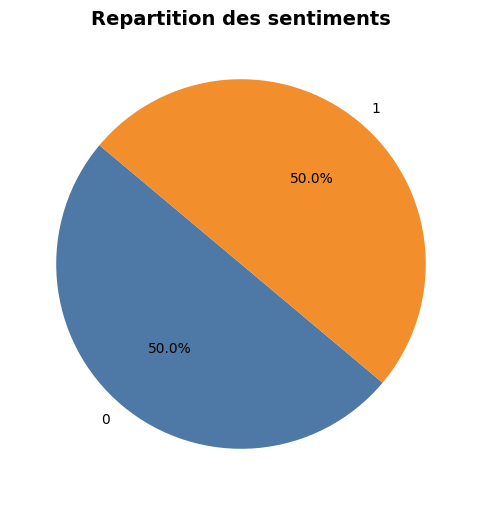

artifact_uri: file:///home/ulrichsama/mlflow_project/mlruns/231745430229609696/53097c539b4c46d4a864f89ecc43b953/artifacts
artifacts: [<FileInfo: file_size=23946, is_dir=False, path='artifacts/bar_chart_pourcentage.jpg'>, <FileInfo: file_size=14634, is_dir=False, path='artifacts/pie_chart_repartition.jpg'>]
[<FileInfo: file_size=23946, is_dir=False, path='artifacts/bar_chart_pourcentage.jpg'>, <FileInfo: file_size=14634, is_dir=False, path='artifacts/pie_chart_repartition.jpg'>]
🏃 View run data_visualisation at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/53097c539b4c46d4a864f89ecc43b953
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [6]:
print(dataset["target"].describe())
repartition = dataset["target"].value_counts()
repartition_pct = dataset["target"].value_counts(normalize=True) * 100

with mlflow.start_run(run_name="data_visualisation"):

    # ==================================================
    # GRAPHIQUE 1 : Le Pie Chart
    # ==================================================
    fig1, ax1 = plt.subplots(figsize=(6, 6))
    ax1.pie(
        repartition,
        labels=repartition.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=["#4e79a7", "#f28e2b"]
    )
    ax1.set_title("Repartition des sentiments", fontsize=14, weight="bold")
    mlflow.log_figure(fig1, "pie_chart_repartition.jpg")
    plt.show()
    plt.close(fig1)


    # ==================================================
    # GRAPHIQUE 2 : Le Bar Chart (Histogramme)
    # ==================================================
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    bars = ax2.bar(
        repartition_pct.index,
        repartition_pct.values, 
        color=["#4e79a7", "#f28e2b"]
    )
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(
            f"{height:.1f}%",  # Texte à afficher
            xy=(
                bar.get_x() + bar.get_width() / 2,
                height,
            ),  # Position (x, y)
            xytext=(0, 3),  # Décalage de 3 points vers le haut
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            weight="bold",
        )
    ax2.set_title("Répartition en pourcentage des émotions", fontsize=14, weight="bold")
    ax2.set_xlabel("Emotions")
    ax2.set_ylabel("Repartition")

    # Log du deuxième graphique (dans le même dossier 'plots')
    mlflow.log_figure(fig2, "bar_chart_pourcentage.jpg")
    print("artifact_uri:", mlflow.get_artifact_uri())
    print("artifacts:", mlflow.artifacts.list_artifacts(mlflow.get_artifact_uri()))
    print(mlflow.artifacts.list_artifacts(mlflow.get_artifact_uri()))
    plt.close(fig2)


In [7]:
with mlflow.start_run(run_name="data_statistics"):
    # Logger les statistiques du dataset
    mlflow.log_param("sentiments_0", int(repartition[0]))
    mlflow.log_param("sentiments_1", int(repartition[1]))
    mlflow.log_param("sentiments_0_pct", f"{repartition_pct[0]:.2f}%")
    mlflow.log_param("sentiments_1_pct", f"{repartition_pct[1]:.2f}%")
    mlflow.log_param("total_samples", len(dataset))
    
    print("✓ Statistics logged successfully!")
    print(f"  - Sentiment 0: {repartition[0]} samples ({repartition_pct[0]:.2f}%)")
    print(f"  - Sentiment 1: {repartition[1]} samples ({repartition_pct[1]:.2f}%)")

✓ Statistics logged successfully!
  - Sentiment 0: 800000 samples (50.00%)
  - Sentiment 1: 800000 samples (50.00%)
🏃 View run data_statistics at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/41b4ca13bf974c12abcb528c7376ef75
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [8]:
SAMPLING_RATIO = 0.02
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(dataset["text"], dataset["target"], train_size=SAMPLING_RATIO, stratify=dataset["target"], random_state=RANDOM_STATE)

repartition = y_train.value_counts()
repartition_pct = y_train.value_counts(normalize=True) * 100
print(repartition)
with mlflow.start_run(run_name="data_sampling"):
    mlflow.log_param("RANDOM_STATE", RANDOM_STATE)
    mlflow.log_param("SAMPLING_RATIO", SAMPLING_RATIO)
    

target
0    16000
1    16000
Name: count, dtype: int64
🏃 View run data_sampling at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/78dc6ba67f1443b2b0f7bfe697ca0e3a
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [9]:
# Dictionnaire des emojis - À compléter selon vos besoins
with open('dict_emojis.json', 'r', encoding='utf-8') as fichier:
    # Transforme le contenu du fichier JSON en dictionnaire Python
    dict_emojis = json.load(fichier)

try:
    with open('stopwords.txt', 'r', encoding='utf-8') as fichier:
        stopwords = set(ligne.strip() for ligne in fichier if ligne.strip())
        
    print(f"{len(stopwords)} stopwords chargés avec succès !")
except FileNotFoundError:
    print("Erreur : Le fichier 'stopwords.txt' est introuvable.")

423 stopwords chargés avec succès !


In [10]:
try:
    nlp_models = {
        "fr": spacy.load("fr_core_news_sm"),
        "en": spacy.load("en_core_web_sm")
    }
    
except OSError:
    print("Erreur : Le modèle SpaCy n'est pas installé. Lancez : python -m spacy download fr_core_news_sm")

stemmers = {
    "fr": SnowballStemmer("french"),
    "en": SnowballStemmer("english")
}

def preprocess_text(tweet, stem_or_lem="lem"):
    if isinstance(tweet, list):
        tweet = " ".join(str(element) for element in tweet)
        
    # On force la conversion en texte (pour éviter les crashs si une ligne est vide/NaN)
    tweet = str(tweet)
    try:
        langue_detectee = detect(tweet)
    except LangDetectException:
        langue_detectee = "en" # Valeur par défaut si le texte est vide ou indétectable
        
    # Si la langue n'est ni anglais ni français, on force l'anglais par défaut
    if langue_detectee not in ["fr", "en"]:
        langue_detectee = "en"

    texte = re.sub(r'http\S+|www\S+|https\S+', '', tweet, flags=re.MULTILINE)
    texte = re.sub(r'@\w+', '', texte)
    texte = re.sub(r'#\w+', '', texte)
    texte = emoji.demojize(texte, language=langue_detectee)
    for emoticon, valeur_texte in dict_emojis[langue_detectee].items():
        texte = texte.replace(emoticon, f" {valeur_texte} ")
    texte = re.sub(r'\s+', ' ', texte).strip()

    doc = nlp_models[langue_detectee](texte)
    mots =[]
    for token in doc:
        if token.is_punct or token.is_space:
            continue  
        mot_original = token.text.lower()
        if stem_or_lem == "lem":
            mot_transforme = token.lemma_.lower()
        elif stem_or_lem == "stem":
            mot_transforme = stemmers[langue_detectee].stem(mot_original)
            
        if mot_original not in stopwords and mot_transforme not in stopwords:
            mots.append(mot_transforme)
    return mots
    

# Test et logging dans MLflow
with mlflow.start_run(run_name="text_preprocessing"):
    example_text = "This is a sample tweet with @user and http://example.com :) !!!"
    processed = preprocess_text(example_text)
    print(f"Original: {example_text}")
    print(f"Processed: {processed}")
    

Original: This is a sample tweet with @user and http://example.com :) !!!
Processed: ['sample', 'tweet', 'smile']
🏃 View run text_preprocessing at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/d3c6ba603d7549518e7810c3b9ba62f5
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [11]:
# Division train/test stratifiée


X_train1, X_test1, y_train1, y_test1 = train_test_split(X_train, y_train, test_size=0.15, random_state=90, stratify=y_train)
with mlflow.start_run(run_name="data_splitting"):
    repartition = y_train1.value_counts()
    repartition_pct = y_train1.value_counts(normalize=True) * 100
    mlflow.log_param("TEST SIZE", 0.15)
    mlflow.log_param("RANDOM STATE", 90)
    mlflow.log_param("X_train", X_train1)
    mlflow.log_param("y_train", y_train1)
    mlflow.log_param("X_test", X_test1)
    mlflow.log_param("y_test", y_test1)
    print(len(X_test1))
    

4800
🏃 View run data_splitting at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/4030db6a61b846dc9fcc9658d6918aae
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [12]:
texte_traitee_train = []
texte_traitee_test = []
for index, ligne in X_train1.items(): 
    texte_traitee_train.append(preprocess_text(ligne))     
for index, ligne in X_test1.items():
    texte_traitee_test.append(preprocess_text(ligne))
X_train1["pretrained"] = texte_traitee_train
X_test1["pretrained"] = texte_traitee_test

In [13]:
textes_finaux_train = [" ".join(lst) for lst in texte_traitee_train]
textes_finaux_test = [" ".join(lst) for lst in texte_traitee_test]
X_train1['final_processed_text'] = textes_finaux_train
X_test1['final_processed_text'] = textes_finaux_test

In [14]:
print(X_train1)

263470                  @dmplace Yeah my app has like a 2 1/2 star rat...
705036                               Thiiuu  I think I'm getting ill -.-'
1237915                 Seems like erryone is working on their beach b...
727630                  I will soon requre an rss aggregator for my rs...
1532176                 While going through my purse to find nail clip...
                                              ...                        
326894                  it's only been 46 minutes? UGH. It feels like ...
1118137                 @crackedknuckles lol thts what i thought curti...
330146                    just another night another dream wasted on you 
pretrained              [[yeah, app, 2, 1/2, star, rating, lol], [thii...
final_processed_text    [yeah app 2 1/2 star rating lol, thiiuu ill, e...
Name: text, Length: 27202, dtype: object


🏃 View run tfidf_vectorization at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/25f036d1576e4a66b7374e0d7fc11b38
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696
(27200, 3578)
(27200,)
(4800, 3578)
(4800,)


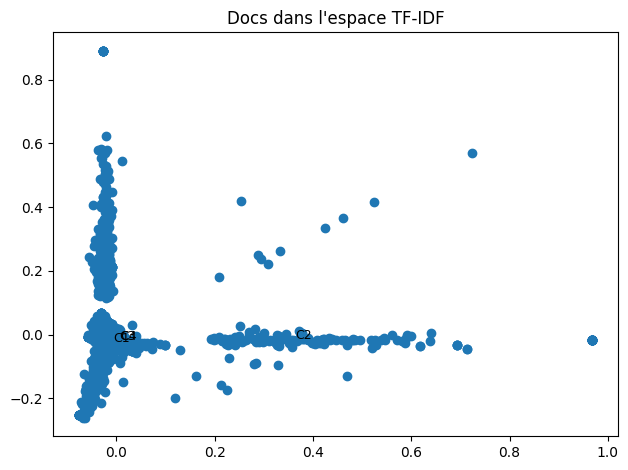

In [15]:
from sklearn.decomposition import PCA

with mlflow.start_run(run_name="tfidf_vectorization"): 
    min_df = 5
    max_df = 10000  
    stopword = "english" 
    tfidf = TfidfVectorizer(min_df=min_df, max_df=max_df, stop_words=stopword)
    tfidf.fit(X_train1["final_processed_text"])
    X_train_tfidf = tfidf.transform(X_train1["final_processed_text"])
    X_test_tfidf = tfidf.transform(X_test1["final_processed_text"])
    df_Xtest_tfidf = pd.DataFrame(
        X_test_tfidf.toarray(), 
        columns=tfidf.get_feature_names_out(),
        index=[f"C{i+1}" for i in range(len(X_test1["final_processed_text"]))]
    )
    
    df_Xtest_tfidf.to_csv("./artifacts/X_test_tfidf.csv")
    
    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_test_tfidf.toarray())
    plt.scatter(coords[:,0], coords[:,1])
    for i, label in enumerate(["C1","C2","C3","C4"]):
        plt.text(coords[i,0]+0.02, coords[i,1], label, fontsize=9)
    plt.title("Docs dans l'espace TF-IDF")
    plt.tight_layout()

    
    mlflow.log_params({
        "min_df": min_df,
        "mac_df": max_df,
        "stop_words": stopword
        })
    mlflow.log_metric("Taille_vocabulaire", len(tfidf.vocabulary_))
    mlflow.log_artifact("artifacts/X_test_tfidf.csv", "tfidf_results")
print(X_train_tfidf.shape)
print(y_train1.shape)
print(X_test_tfidf.shape)
print(y_test1.shape)

In [16]:
def evaluate_and_log_model(model, model_name, X_train, X_test, y_train, y_test, **model_params):
    with mlflow.start_run(run_name=model_name): 
        if model_params:
            model.set_params(**model_params)

        # Entrainement de modèle et calcul de la durée d'entrainement
        start_time = time.time()
        model.fit(X_train, y_train)
        end_time = time.time()
        training_time = end_time - start_time

        # Prédictions
        predictions = model.predict(X_test)

        accuracy = accuracy_score(y_test, predictions)
        f1 = f1_score(y_test, predictions, average="weighted")
        auc = roc_auc_score(y_test, predictions)
        metrics = {
            "Temps_entrainement_secondes": training_time,
            "Accuracy": accuracy,
            "f1_score": f1,
            "AUC_ROC_Score": auc,
        }
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, name=model_name)
    return metrics
# Test de la fonction - À décommenter après implémentation

In [17]:
models_to_compare = {
    "Regression_Logistic": LogisticRegression(),
    "RandomForestClassifier": RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 42),
    "GradientBoosting": GradientBoostingClassifier()
}

results = {}
for index, value in models_to_compare.items():
    results[index] = evaluate_and_log_model(value, index, X_train_tfidf, X_test_tfidf, y_train1, y_test1)


2026/07/09 11:25:58 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Regression_Logistic at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/966959f837b74d66ab485296d183c304
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


2026/07/09 11:26:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run RandomForestClassifier at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/806e4890f93748f687c5ad71f739778c
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


2026/07/09 11:26:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run GradientBoosting at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/e9543f8a0f92441b8a8e69334eb51556
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [18]:
from sklearn.model_selection import GridSearchCV, ParameterGrid

def log_gridsearch_to_mlflow(estimator, param_grid, X_train, y_train, X_test, y_test, cv=5, scoring='accuracy'):
    with mlflow.start_run(run_name="Optimisation") as parent_run:
        grid = GridSearchCV(
            estimator=estimator, 
            param_grid=param_grid, 
            cv=cv, 
            scoring=scoring )
        grid.fit(X_train, y_train)
            
        
        cv_results = grid.cv_results_
        nombre_configs = len(cv_results['params'])
        
        for i in range(nombre_configs):
            
            with mlflow.start_run(run_name=f"Optimisation_fils{i+1}", nested=True) as child_run:
                
                # Logger les paramètres spécifiques à cette configuration
                mlflow.log_params(cv_results['params'][i])
                
                # Logger les scores moyens et écarts-types de la validation croisée
                mlflow.log_metric(f"cv_mean_{scoring}", cv_results['mean_test_score'][i])
                mlflow.log_metric(f"cv_std_{scoring}", cv_results['std_test_score'][i])
                mlflow.log_metric("fit_time_seconds", cv_results['mean_fit_time'][i])

        # 4. Logger les meilleurs paramètres et le meilleur modèle dans le run parent
        best_params = grid.best_params_
        best_model = grid.best_estimator_
        
        # On préfixe les clés par "best_" pour les retrouver facilement dans l'UI MLflow
        mlflow.log_params({f"best_{k}": v for k, v in best_params.items()})
        mlflow.sklearn.log_model(best_model, name="meilleur_modele")
        
        # 5. Évaluer le meilleur modèle sur le test set
        # Utilisation de get_scorer pour calculer la même métrique que celle du GridSearch
        scorer = get_scorer(scoring)
        test_score = scorer(best_model, X_test, y_test)
        
        mlflow.log_metric(f"test_{scoring}", test_score)
        
        # Affichage en console pour le suivi
        print("\n✅ Optimisation terminée !")
        print(f"Meilleurs paramètres : {best_params}")
        print(f"Score de validation croisée ({scoring}) : {grid.best_score_:.4f}")
        print(f"Score sur le jeu de test ({scoring}) : {test_score:.4f}")
        return best_model, parent_run.info.run_id

# Configuration de la grille de paramètres
param_grid = {
    # À compléter : définissez votre grille pour le meilleur modèle
    # Exemple pour LogisticRegression :
    'C': [0.1, 1.0, 10.0, 15.0, 20.0],
    'max_iter': [1000, 2000, 3000, 4000, 5000]
}


In [19]:
model_best, id_best_model = log_gridsearch_to_mlflow(models_to_compare["Regression_Logistic"], param_grid, X_train_tfidf, y_train1, X_test_tfidf, y_test1, cv=5, scoring='accuracy')

🏃 View run Optimisation_fils1 at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/b90c87d5bc5e4b74ba0e2e9a957d6e03
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696
🏃 View run Optimisation_fils2 at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/fa2238ac84fd40369a2e231e71ffffbd
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696
🏃 View run Optimisation_fils3 at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/0ed53beeb85648e49a08ef0d8ed979b9
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696
🏃 View run Optimisation_fils4 at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/fe7a7b2c421940b0b16898017fc579a0
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696
🏃 View run Optimisation_fils5 at: https://ulrichsama.pyt

2026/07/09 11:27:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✅ Optimisation terminée !
Meilleurs paramètres : {'C': 1.0, 'max_iter': 1000}
Score de validation croisée (accuracy) : 0.7125
Score sur le jeu de test (accuracy) : 0.7148
🏃 View run Optimisation at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/3370f3980c014bc4b56bdd775df3b236
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [20]:
model_name = "meilleur_modele"
client = MlflowClient()

run_id = id_best_model
artifact_path = "meilleur_modele"
# 2. Enregistrez votre meilleur modèle avec mlflow.register_model()
model_uri = f"runs:/{run_id}/{artifact_path}"
model_version_info = mlflow.register_model(model_uri=model_uri, name=model_name)

# On récupère le numéro de version (qui s'incrémente automatiquement)
version = model_version_info.version 
version_str = str(version)
print(f"Modèle enregistré sous le nom '{model_name}', version : {version}")

# 3. Utilisez MlflowClient pour gérer le modèle
client = MlflowClient()

# 3.1 Ajouter des descriptions
# Description du modèle global
client.update_registered_model(
    name=model_name,
    description="Modèle de classification optimisé pour prédire la catégorie cible."
)

# Tags
client.set_registered_model_tag(
    name=model_name, 
    key="tache", 
    value="classification_binaire"
)
client.set_model_version_tag(
    name=model_name, 
    version=version_str, 
    key="statut_validation", 
    value="approuve_par_data_scientist"
)
print("✅ Métadonnées et tags ajoutés.")

print("\n3. Gestion des transitions (Staging -> Production)...")

# Pour 'Staging'
client.set_registered_model_alias(
    name=model_name,
    alias="Staging",
    version=version_str
)
print(f"✅ L'alias 'Staging' a été assigné à la version {version_str}.")

# Pour 'Production' (déplacera automatiquement l'alias s'il est déjà sur une autre version)
client.set_registered_model_alias(
    name=model_name,
    alias="Production",
    version=version_str
)
print(f"✅ L'alias 'Production' a été assigné à la version {version_str}.")

Registered model 'meilleur_modele' already exists. Creating a new version of this model...
2026/07/09 11:27:51 WARNING mlflow.tracking._model_registry.fluent: Run with id 3370f3980c014bc4b56bdd775df3b236 has no artifacts at artifact path 'meilleur_modele', registering model based on models:/m-7a1b80716fb04bc584cca6dc6a4590cc instead
2026/07/09 11:27:52 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: meilleur_modele, version 13
Created version '13' of model 'meilleur_modele'.


Modèle enregistré sous le nom 'meilleur_modele', version : 13
✅ Métadonnées et tags ajoutés.

3. Gestion des transitions (Staging -> Production)...
✅ L'alias 'Staging' a été assigné à la version 13.
✅ L'alias 'Production' a été assigné à la version 13.


1. Analyse globale : Extraction des coefficients...
[-0.647472    0.25310649  0.83993272 ...  0.528135    0.86941954
  0.21350684]


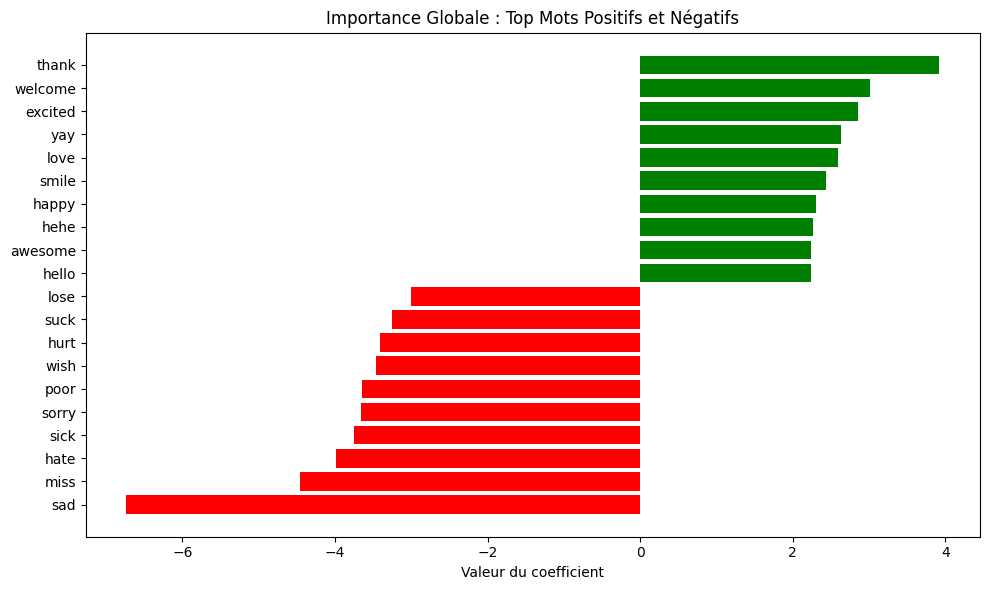

✅ Graphique des coefficients loggé.

2. Analyse locale avec LIME...


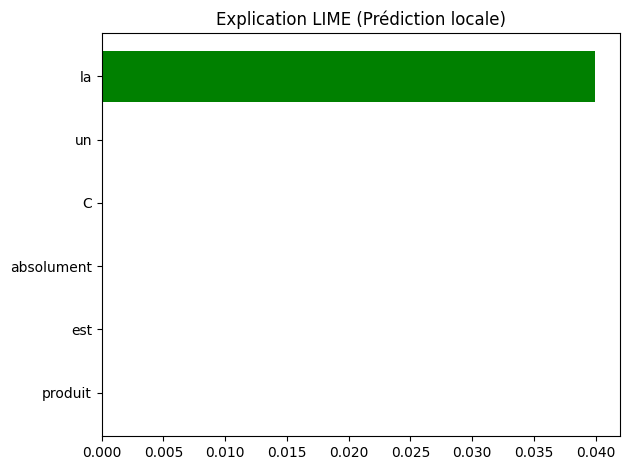

✅ Explications LIME loggées pour l'exemple : 'C'est un produit absolument fantastique mais la livraison a été un peu lente.'
🏃 View run model_interpretability at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696/runs/ef80444332fa4f04a67cdc35f6bedf06
🧪 View experiment at: https://ulrichsama.pythonanywhere.com/#/experiments/231745430229609696


In [23]:
# Note : Assurez-vous d'avoir en mémoire votre 'vectorizer' et votre 'model' entraînés
# Par exemple : model = LogisticRegression(), vectorizer = TfidfVectorizer()

with mlflow.start_run(run_name="model_interpretability"):
    
    print("1. Analyse globale : Extraction des coefficients...")
    # 1. Analysez les coefficients du modèle (si c'est un modèle linéaire)
    if hasattr(model_best, 'coef_'):
        # On récupère le vocabulaire et les poids
        feature_names = tfidf.get_feature_names_out()
        coefs = model_best.coef_[0] # [0] car c'est souvent une classification binaire
        print(coefs)
        # On isole les 10 mots les plus négatifs et les 10 les plus positifs
        top_positive_indices = np.argsort(coefs)[-10:]
        top_negative_indices = np.argsort(coefs)[:10]
        top_indices = np.concatenate([top_negative_indices, top_positive_indices])
        
        # 2. Créez des visualisations des mots les plus importants
        fig_coef, ax = plt.subplots(figsize=(10, 6))
        colors = ['red' if c < 0 else 'green' for c in coefs[top_indices]]
        ax.barh(np.arange(20), coefs[top_indices], color=colors)
        ax.set_yticks(np.arange(20))
        ax.set_yticklabels(feature_names[top_indices])
        plt.title("Importance Globale : Top Mots Positifs et Négatifs")
        plt.xlabel("Valeur du coefficient")
        plt.tight_layout()
        plt.show()
        # 5. Sauvegardez la visualisation dans MLflow
        mlflow.log_figure(fig_coef, "interpretability/global_coefficients.png")
        plt.close(fig_coef)
        print("✅ Graphique des coefficients loggé.")
    else:
        print("Le modèle n'a pas d'attribut 'coef_'. Étape ignorée.")

    print("\n2. Analyse locale avec LIME...")
    # 3. Configurez LIME pour l'interprétation locale
    # LIME a besoin d'avaler du texte brut et de cracher des probabilités.
    # make_pipeline est parfait pour lier le vectoriseur et le modèle en une seule fonction.
    pipeline = make_pipeline(tfidf, model_best)
    
    # Remplacer les noms de classes par vos vraies catégories si besoin
    explainer = LimeTextExplainer(class_names=['Classe_Negative', 'Classe_Positive'])
    
    # 4. Testez sur des exemples personnalisés
    texte_exemple = "C'est un produit absolument fantastique mais la livraison a été un peu lente."
    
    # On génère l'explication (nécessite predict_proba)
    if hasattr(model_best, 'predict_proba'):
        explanation = explainer.explain_instance(
            texte_exemple, 
            pipeline.predict_proba, 
            num_features=6 # Nombre de mots à mettre en avant
        )
        
        # 5. Sauvegardez toutes les visualisations avec mlflow.log_figure()
        # LIME possède une méthode native pour exporter un graphique Matplotlib
        fig_lime = explanation.as_pyplot_figure()
        plt.title("Explication LIME (Prédiction locale)")
        plt.tight_layout()
        mlflow.log_figure(fig_lime, "interpretability/lime_local_explanation.png")
        plt.show()
        plt.close(fig_lime)
        
        # BONUS TRÈS UTILE : Sauvegarder la version HTML interactive de LIME
        html_path = "lime_report.html"
        explanation.save_to_file(html_path)
        mlflow.log_artifact(html_path, "interpretability")
        
        print(f"✅ Explications LIME loggées pour l'exemple : '{texte_exemple}'")
    else:
        print("Le modèle ne supporte pas 'predict_proba'. LIME a besoin de probabilités pour fonctionner.")